# 📈 AI Powered Stock Market Predictor
This Jupyter Notebook demonstrates building an LSTM model to predict stock market prices using historical data.

In [1]:
!pip install yfinance pandas numpy scikit-learn matplotlib tensorflow


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


## Download Stock Data

In [3]:
df = pd.read_csv('sample_stock_data.csv')  # Use your ready CSV file
print(df.head())

         Date        Open        High         Low       Close   Adj Close  \
0  2023-01-01  165.361584  173.398070  140.667525  157.977363  171.291917   
1  2023-01-02  155.276200  174.353292  145.442744  167.360029  162.820584   
2  2023-01-03  150.059789  171.809781  142.509682  151.893212  167.153302   
3  2023-01-04  153.376682  172.578462  140.498889  169.575819  166.976949   
4  2023-01-05  160.169524  175.044318  143.766889  167.016230  151.281609   

    Volume  
0  2870561  
1  1800214  
2  1379766  
3  3037415  
4  1132957  


## Data Preprocessing

In [4]:
data = df.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil(len(dataset) * 0.8))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training_data_len), :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape input for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

## Build LSTM Model

In [5]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

## Train the Model

In [6]:
model.fit(x_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
1/1 [==============================] - 5s 5s/step - loss: 0.3953
Epoch 2/10
1/1 [==============================] - 0s 61ms/step - loss: 0.3252
Epoch 3/10
1/1 [==============================] - 0s 55ms/step - loss: 0.2635
Epoch 4/10
1/1 [==============================] - 0s 57ms/step - loss: 0.2005
Epoch 5/10
1/1 [==============================] - 0s 55ms/step - loss: 0.1785
Epoch 6/10
1/1 [==============================] - 0s 55ms/step - loss: 0.1398
Epoch 7/10
1/1 [==============================] - 0s 54ms/step - loss: 0.1093
Epoch 8/10
1/1 [==============================] - 0s 56ms/step - loss: 0.1075
Epoch 9/10
1/1 [==============================] - 0s 53ms/step - loss: 0.1625
Epoch 10/10
1/1 [==============================] - 0s 56ms/step - loss: 0.1852


## Test the Model

In [7]:
test_data = scaled_data[training_data_len - 60:, :]
x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predictions
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

1/1 [==============================] - 1s 1s/step


## Evaluate the Model

In [8]:
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 12.77967763053626


## Visualize the Results

C:\Users\Ribhu\AppData\Local\Temp\ipykernel_17328\1927714792.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


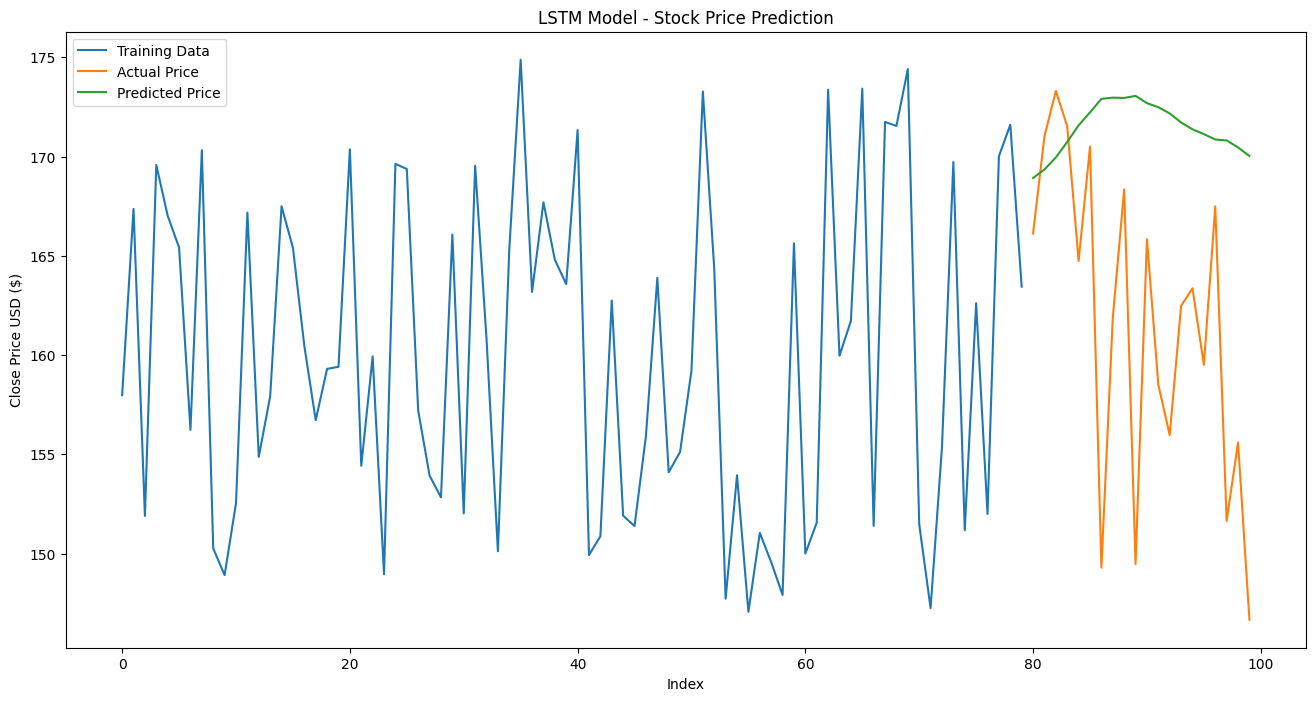

In [9]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('LSTM Model - Stock Price Prediction')
plt.xlabel('Index')
plt.ylabel('Close Price USD ($)')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend()
plt.show()

## Predict Next Day Price

In [10]:
last_60_days = data[-60:].values
last_60_days_scaled = scaler.transform(last_60_days)

X_test = []
X_test.append(last_60_days_scaled)
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

pred_price = model.predict(X_test)
pred_price = scaler.inverse_transform(pred_price)
print("Predicted next day price:", pred_price[0][0])

1/1 [==============================] - 0s 37ms/step
Predicted next day price: 169.2728


In [11]:
# Save entire model to a file
model.save("stock_predictor_model.h5")

print("Model Saved Successfully!")


Model Saved Successfully!


In [12]:
# After fitting scaler & training model:
import joblib

model.save("stock_predictor_model.h5")
joblib.dump(scaler, 'scaler.save')


['scaler.save']